# Partea 1 – Analiza si intelegerea setului de date
## Dataset: Australian Credit Approval (UCI)

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns




## 1. Descrierea generala a setului de date si a variabilei tinta

Sursa:[Australian Credit Approval](https://archive.ics.uci.edu/ml/datasets/Statlog+%28Australian+Credit+Approval%29)

Scopul problemei: Prezicerea daca o cerere de credit este aprobata sau respinsa pe baza unor caracteristici personale si financiare. Variabila tinta este **A15**.

Tipul problemei: Clasificare binara (0 = respins, 1 = aprobat)

Numarul de trasaturi:690
Tipul trasaturilor:

| Variable Name | Role    | Type        | Missing Values |
|---------------|---------|-------------|----------------|
| A1            | Feature | Categorical | no             |
| A2            | Feature | Continuous  | no             |  
| A3            | Feature | Continuous  | no             |
| A4            | Feature | Categorical | no             |
| A5            | Feature | Categorical | no             |
| A6            | Feature | Categorical | no             |
| A7            | Feature | Continuous  | no             |
| A8            | Feature | Categorical | no             |
| A9            | Feature | Categorical | no             |
| A10           | Feature | Continuous  | no             |
| A11           | Feature | Categorical | no             |
| A12           | Feature | Categorical | no             |
| A13           | Feature | Continuous  | no             |
| A14           | Feature | Continuous  | no             |
| A15           | Target  | Categorical | no             |

In [35]:
# Citirea setului de date
col_names = ['A1','A2','A3','A4','A5','A6','A7','A8','A9','A10','A11','A12','A13','A14','A15']
df = pd.read_csv('australian.dat', sep=' ', header=None, names=col_names)

# Numarul de instante si trasaturi
n_instante, n_trasaturi = df.shape
print(f"Numar de instante (randuri): {n_instante}")
print(f"Numar de trasaturi (coloane, inclusiv target): {n_trasaturi}")
print(f"Numar de trasaturi (fara target): {n_trasaturi - 1}")
print()
print("Primele 5 randuri:")
df.head()

Numar de instante (randuri): 690
Numar de trasaturi (coloane, inclusiv target): 15
Numar de trasaturi (fara target): 14

Primele 5 randuri:


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15
0,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1



## 2. Distributia claselor

In [36]:
class_counts = df['A15'].value_counts().sort_index()
# print(class_counts)
# print(class_counts.sum())
class_pct = class_counts/class_counts.sum() * 100

dist = pd.DataFrame({

    'Nr. instante': class_counts.values,
    'Procent (%)': class_pct.values.round(2)
})
print("Distributia claselor:")
print(dist)

Distributia claselor:
   Nr. instante  Procent (%)
0           383        55.51
1           307        44.49


C:\Users\Tavi\AppData\Local\Temp\ipykernel_2028\2997662741.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='A15', data=df, palette='Set1', ax=axes[0])
C:\Users\Tavi\AppData\Local\Temp\ipykernel_2028\2997662741.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['0 (Respins)', '1 (Aprobat)'])


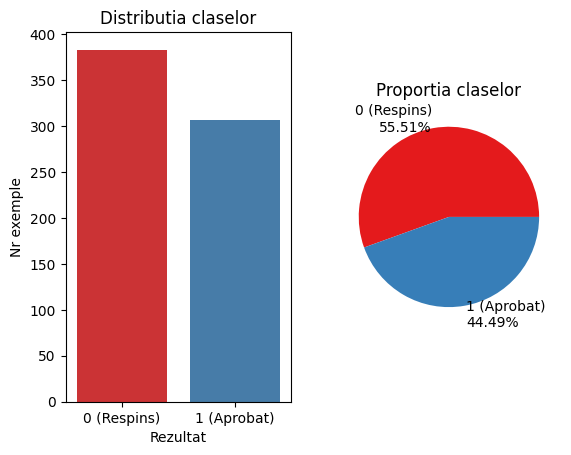

Dataset-ul este relativ echilibrat:
   clasa 0: 55.51%, clasa 1: 44.49%


In [37]:

fig, axes = plt.subplots(1, 2)

# Countplot
sns.countplot(x='A15', data=df, palette='Set1', ax=axes[0])
axes[0].set_title('Distributia claselor')
axes[0].set_xlabel('Rezultat')
axes[0].set_ylabel('Nr exemple')
axes[0].set_xticklabels(['0 (Respins)', '1 (Aprobat)'])


# Pie chart
axes[1].pie(class_counts.values, labels= [f'0 (Respins)\n{class_pct[0].round(2)}%', f'1 (Aprobat)\n{class_pct[1].round(2)}%'],
            colors=sns.color_palette('Set1'))
axes[1].set_title('Proportia claselor')

plt.show()

print("Dataset-ul este relativ echilibrat:")
print(f"   clasa 0: {class_pct[0]:.2f}%, clasa 1: {class_pct[1]:.2f}%")


## 3. Identificarea valorilor lipsa si a problemelor de calitate

In [38]:
missing = df.isnull().sum()
# print(df.isnull())
# print(missing)
missing_pct = (missing / len(df)) * 100
missing_table = pd.DataFrame({'Nr. valori lipsa': missing, 'Procent (%)': missing_pct.round(2)})
print("Valori lipsa per trasatura:")
print(missing_table)
print(f"\nTotal valori lipsa: {missing.sum()}")

Valori lipsa per trasatura:
     Nr. valori lipsa  Procent (%)
A1                  0          0.0
A2                  0          0.0
A3                  0          0.0
A4                  0          0.0
A5                  0          0.0
A6                  0          0.0
A7                  0          0.0
A8                  0          0.0
A9                  0          0.0
A10                 0          0.0
A11                 0          0.0
A12                 0          0.0
A13                 0          0.0
A14                 0          0.0
A15                 0          0.0

Total valori lipsa: 0


In [39]:
n_dup = df.duplicated().sum()
pct_dup = (n_dup / len(df)) * 100
print(f"Numar de randuri duplicate: {n_dup}")

Numar de randuri duplicate: 0


### Cazul in care ar fi existat valori lipsa/duplicate:

In [42]:
df_copy = df.copy()

# Eliminare duplicate
if n_dup > 0:
    df_copy = df_copy.drop_duplicates()
    print(f"Randuri duplicate eliminate: {n_dup}")

num_cols = ['A2', 'A3', 'A7', 'A10', 'A13', 'A14']
cat_cols = ['A1', 'A4', 'A5', 'A6', 'A8', 'A9', 'A11', 'A12']


#In cazul in care lipsesc valori numerice putem pune valoarea mediana nefiind afectata de outliers atat de mult
for col in num_cols:
    if df_copy[col].isnull().sum() > 0:
        median_val = df_copy[col].median()
        df_copy[col] = df_copy[col].fillna(median_val)
        print(f"  {col}: imputat cu mediana ({median_val})")


#In cazul in care lipsesc mai multe valori categorice care ar putea face diferenta mai mult putem opta 
# intre a pune valoarea cea mai comuna din categoria respectiva sau daca 
# dataset ul ne permite fiind destul de mare,sa stergem complet randul
if len(df_copy) > 1000:
    df_copy = df_copy.dropna(subset=cat_cols,thresh=len(cat_cols)/2)
else:
    for col in cat_cols:
        if df_copy[col].isnull().sum() > 0:
            mode_val = df_copy[col].mode()[0]
            df_copy[col] = df_copy[col].fillna(mode_val)
            print(f"  {col}: imputat cu moda ({mode_val})")

# df_copy.to_csv("australian_clean.dat", sep=" ", header=False, index=False)
df_clean=df_copy

## 4a. Analiza trasaturilor numerice

In [ ]:

num_cols = ['A2', 'A3', 'A7', 'A10', 'A13', 'A14']
stats = df_clean[num_cols].describe().T
stats = stats.round(3)
print("Statistici descriptive pentru trasaturile numerice:")
print(stats.to_string())

Statistici descriptive pentru trasaturile numerice:
     count      mean       std    min     25%      50%      75%        max
A2   690.0    31.568    11.853  13.75  22.670   28.625   37.707      80.25
A3   690.0     4.759     4.978   0.00   1.000    2.750    7.208      28.00
A7   690.0     2.223     3.347   0.00   0.165    1.000    2.625      28.50
A10  690.0     2.400     4.863   0.00   0.000    0.000    3.000      67.00
A13  690.0   184.014   172.159   0.00  80.000  160.000  272.000    2000.00
A14  690.0  1018.386  5210.103   1.00   1.000    6.000  396.500  100001.00


## 4b. Analiza trasaturilor categoriale